In [1]:
import os
os.sys.path.append('/data/scratch/globc/bonassies/workspace/swot_for_flood')
import geopandas as gpd
import configparser
from pathlib import Path
from matplotlib import pyplot as plt
import seaborn as sns
from cmap import Colormap

from core.swot_project import SwotProject
from core.plot_raster import PlotRaster

import xarray as xr
import numpy as np
from skimage.filters import median
import geopandas as gpd


main_path = "/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Chinon_T2D"

# Plotting for Chinon

This notebook uses the rasters generated before to plot the results of the Chinon exercise. The rasters are stored in the `rasters` folder and the plots are stored in the `plots` folder.

First, we need to load the project:

In [2]:
config = configparser.ConfigParser()
config.read(main_path + '/config.cfg')

# print(type(config),dict(config['CONFIG']))

['/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Chinon_T2D/config.cfg']

In [3]:
swot_project = SwotProject(config)
# print(swot_project)

Data path already exists in /data/scratch/globc/bonassies/data or download is set to False
SWOT data already exists in /data/scratch/globc/bonassies/data/SWOT or download is set to False
SWOT project already exists in /data/scratch/globc/bonassies/data/SWOT/Chinon_T2D or download is set to False
Geopackage already exists in /data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Chinon_T2D/gpkg_combined or make_gpkg is set to False
TIFF path already exists in /data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Chinon_T2D/rasters or make_tiff is set to False
No automatic download, please use the Downloader object to download the data
No pixc files found, please check the SWOT_PATH of download the data


In [4]:
swot_project.find_raster()
print(swot_project.rasters_list)


[PosixPath('/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Chinon_T2D/rasters/SWOT_epsg2154_20250522T221758_combined.tif'), PosixPath('/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Chinon_T2D/rasters/SWOT_epsg2154_20240803T194650_combined.tif'), PosixPath('/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Chinon_T2D/rasters/SWOT_epsg2154_20251105T201836_combined.tif'), PosixPath('/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Chinon_T2D/rasters/SWOT_epsg2154_20240512T084623_combined.tif'), PosixPath('/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Chinon_T2D/rasters/SWOT_epsg2154_20251126T170330_combined.tif'), PosixPath('/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Chinon_T2D/rasters/SWOT_epsg2154_20241116T033206_combined.tif'), PosixPath('/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Chinon_T2D/rasters/SWOT_epsg2154_20240310T183109_combined.tif'), PosixPath('/data/sc

Then, once loaded, we need to create, load and pre-treat the SWOT data used for plotting.
Here we use the collection object within the project to create a new collection with the dry and flooded times selected.

In [5]:
# takes around 2 minutes for 5 raster files of 1.65Go
swot_project.create_collection()

Opening SWOT raster at time: 2024-03-31 15:16:13


/data/home/globc/bonassies/.conda/envs/conda3.10/lib/python3.10/site-packages/dask/array/chunk.py:279: RuntimeWarning: invalid value encountered in cast
  return x.astype(astype_dtype, **kwargs)
/data/home/globc/bonassies/.conda/envs/conda3.10/lib/python3.10/site-packages/dask/array/chunk.py:279: RuntimeWarning: invalid value encountered in cast
  return x.astype(astype_dtype, **kwargs)


Opening SWOT raster at time: 2024-10-05 10:01:59


/data/home/globc/bonassies/.conda/envs/conda3.10/lib/python3.10/site-packages/dask/array/chunk.py:279: RuntimeWarning: invalid value encountered in cast
  return x.astype(astype_dtype, **kwargs)
/data/home/globc/bonassies/.conda/envs/conda3.10/lib/python3.10/site-packages/dask/array/chunk.py:279: RuntimeWarning: invalid value encountered in cast
  return x.astype(astype_dtype, **kwargs)


Opening SWOT raster at time: 2024-08-03 19:46:50


/data/home/globc/bonassies/.conda/envs/conda3.10/lib/python3.10/site-packages/dask/array/chunk.py:279: RuntimeWarning: invalid value encountered in cast
  return x.astype(astype_dtype, **kwargs)
/data/home/globc/bonassies/.conda/envs/conda3.10/lib/python3.10/site-packages/dask/array/chunk.py:279: RuntimeWarning: invalid value encountered in cast
  return x.astype(astype_dtype, **kwargs)


Opening SWOT raster at time: 2024-08-24 16:31:44


/data/home/globc/bonassies/.conda/envs/conda3.10/lib/python3.10/site-packages/dask/array/chunk.py:279: RuntimeWarning: invalid value encountered in cast
  return x.astype(astype_dtype, **kwargs)
/data/home/globc/bonassies/.conda/envs/conda3.10/lib/python3.10/site-packages/dask/array/chunk.py:279: RuntimeWarning: invalid value encountered in cast
  return x.astype(astype_dtype, **kwargs)


Opening SWOT raster at time: 2024-09-14 13:16:51


/data/home/globc/bonassies/.conda/envs/conda3.10/lib/python3.10/site-packages/dask/array/chunk.py:279: RuntimeWarning: invalid value encountered in cast
  return x.astype(astype_dtype, **kwargs)
/data/home/globc/bonassies/.conda/envs/conda3.10/lib/python3.10/site-packages/dask/array/chunk.py:279: RuntimeWarning: invalid value encountered in cast
  return x.astype(astype_dtype, **kwargs)
/data/home/globc/bonassies/.conda/envs/conda3.10/lib/python3.10/site-packages/dask/array/chunk.py:279: RuntimeWarning: invalid value encountered in cast
  return x.astype(astype_dtype, **kwargs)
/data/home/globc/bonassies/.conda/envs/conda3.10/lib/python3.10/site-packages/dask/array/chunk.py:279: RuntimeWarning: invalid value encountered in cast
  return x.astype(astype_dtype, **kwargs)
/data/home/globc/bonassies/.conda/envs/conda3.10/lib/python3.10/site-packages/dask/array/chunk.py:279: RuntimeWarning: invalid value encountered in cast
  return x.astype(astype_dtype, **kwargs)
/data/home/globc/bonassie

We can then create the plot object that we will use to plot the data.

In [6]:
plot_obj = PlotRaster(
    swot_project,
    save_fig=True,
    show_fig=False
    )

In [ ]:
plot_obj.plot_all_rasters(
    "gamma_tot",
    cmap=Colormap("seaborn:mako").to_matplotlib(),
    vmin=0, vmax=1
)

# Animation

In [9]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

data = plot_obj.swot_collection.swot_flood_rasters
data = data.sortby("time")

variables = ["gamma_tot", "sig0", "coherent_power"]
# variables = ["coherent_power"]
for variable in variables:
    if variable == "coherent_power":
        da = np.log10(data.coherent_power) * 10
    elif variable == "sig0":
        da = np.log10(data.sig0) * 10
    else: 
        da = data[variable]

    # remove empty dates
    mask_time = np.full_like(da.time.values, False, dtype=bool)
    for t in da.time.values:
        if np.isnan(da.sel(time=t)).all():
            mask_time[da.time.values == t] = True
    da = da.sel(time=~mask_time)


    fig, ax = plt.subplots(figsize=(12, 8), dpi=100, tight_layout=True)

    ax.spines.right.set_visible(False)
    ax.spines.top.set_visible(False)
    ax.xaxis.set_visible(False)
    ax.yaxis.set_visible(False)

    ax.set_facecolor('black')
    def update(frame):
        tmp = da.isel(time=frame)
        ax.clear()
        if variable == "gamma_tot":
            vmin, vmax = 0.5, 1
        elif variable == "sig0":
            vmin, vmax = -15, 15
        elif variable == "coherent_power":
            vmin, vmax = 60, 80
        da.isel(time=frame).plot(ax=ax, cmap=Colormap("seaborn:mako").to_matplotlib(), vmin=vmin, vmax=vmax, add_colorbar=False) # coherent_power
        ax.set_title(str(da.time.values[frame].astype('datetime64[D]')))
        
        ax.spines.right.set_visible(False)
        ax.spines.top.set_visible(False)
        ax.xaxis.set_visible(False)
        ax.yaxis.set_visible(False)
        ax.set_facecolor('black')

    ani = FuncAnimation(fig, update, frames=len(da.time))

    ani.save(f"/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Chinon_T2D/plots/animation_{variable}.gif", writer=PillowWriter(fps=5))
    
    plt.close(fig)
    del ani

# Flood Occurence on Chinon event

In [10]:
outside_time = [
    # "2024-01-08", 
    # "2024-01-15",
    # "2024-01-26", 
    # "2024-01-29", 
    # "2024-02-05",
    # "2024-04-28", 
    # "2024-05-09", 
    # "2024-05-19", 
    # "2024-05-30"
    ]
# do_left_map = True
variable = "gamma_tot" # "sig0", "coherent_power", "gamma_tot"
occurence_map = xr.zeros_like(swot_project.swot_collection.get_variable(variable, "global", "swot", None).isel(time=0))
n_time = 0
for time in swot_project.list_flood_dates:
    if time in outside_time:
        continue
    # if time not in left_time and not do_left_map:
    #     continue
    if variable == "sig0":
        vmin=-20.
        vmax=40.
        cmap="viridis"
        Chinon_thresholds={"urban":-0, "forest":10, "open":10}
        
    elif variable == "coherent_power":
        vmin=45.
        vmax=85.
        cmap="plasma"
        Chinon_thresholds={"urban":-0, "forest":64, "open":64}
        
    elif variable == "gamma_tot":
        vmin=0.
        vmax=1.
        cmap=Colormap("seaborn:mako").to_matplotlib()
        Chinon_thresholds={"urban":-0, "forest":0.715, "open":0.715}
    
    print(f"Processing time: {time}", flush=True)
    exact_time = swot_project.swot_collection.get_variable(variable, "global", "swot", None).sel(time=time).time[0]
    str_time = exact_time.dt.strftime("%Y%m%dT%H%M%S").values
    
    print("Creating flood mask...", flush=True)
    plot_obj.swot_collection.create_flood_mask(
        variable=variable,
        data_area="global",
        data_type="swot",
        thresholds=Chinon_thresholds,
        time_selection=time,
        add_uncertainty=False,
        threshold_gamma=0.5,
        threshold_SNR=0.5,
        )
    floodmask = swot_project.swot_collection.get_floodmask_from_variable(variable, "swot", "global")
    # Blur the floodmask to remove isolated pixels
    from scipy.ndimage import gaussian_filter
    floodmask_blurred = gaussian_filter(floodmask.values.astype(float), sigma=1)
    
    
    condition = np.logical_and(floodmask.values != 0, floodmask.values < 10) * 1.
    # condition = np.logical_and(data.values != 0, data.values < 20) * 1.
    occurence_map += np.where(condition, 1, 0).reshape(occurence_map.shape)
    n_time += 1

occurence_map = occurence_map / n_time
occurence_map.values = np.where(occurence_map.values == 0, np.nan, occurence_map.values)
occurence_map.values = median(occurence_map.values, np.ones((3,3)))

print("\n"*2)
print("*"*40)
print(n_time, "overpass processed")

Processing time: 2023-11-06
Creating flood mask...


Processing time: 2023-12-18
Creating flood mask...
Processing time: 2024-03-10
Creating flood mask...
Processing time: 2024-03-31
Creating flood mask...
Processing time: 2024-05-12
Creating flood mask...
Processing time: 2024-10-26
Creating flood mask...
Processing time: 2025-02-07
Creating flood mask...
Processing time: 2025-02-28
Creating flood mask...
Processing time: 2026-02-18
Creating flood mask...



****************************************
9 overpass processed


In [11]:
gdf = gpd.read_file("/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Chinon_T2D/mask_not_dh_Chinon.gpkg")
gdf2 = gpd.read_file("/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Chinon_T2D/AOI_T2D.gpkg")

occurence_map.plot(cmap='plasma', vmin=0, vmax=1, figsize=(10,6), cbar_kwargs={"label": "Occurence Frequency"})
# gdf.plot(ax=plt.gca(), facecolor='white', alpha=0.75, edgecolor='black', linewidth=0.5)
gdf2.plot(ax=plt.gca(), facecolor='none', edgecolor='red', linewidth=1)
plt.axis('off')
title ={'gamma_tot':'[a]', 'coherent_power':'[b]', 'sig0':'[c]'}
plt.title(title[variable], fontsize=16)
plt.savefig(f"/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Chinon_T2D/Chinon_flood_occurence_map_{variable}_without_mask.png", dpi=300, bbox_inches='tight')
plt.close()

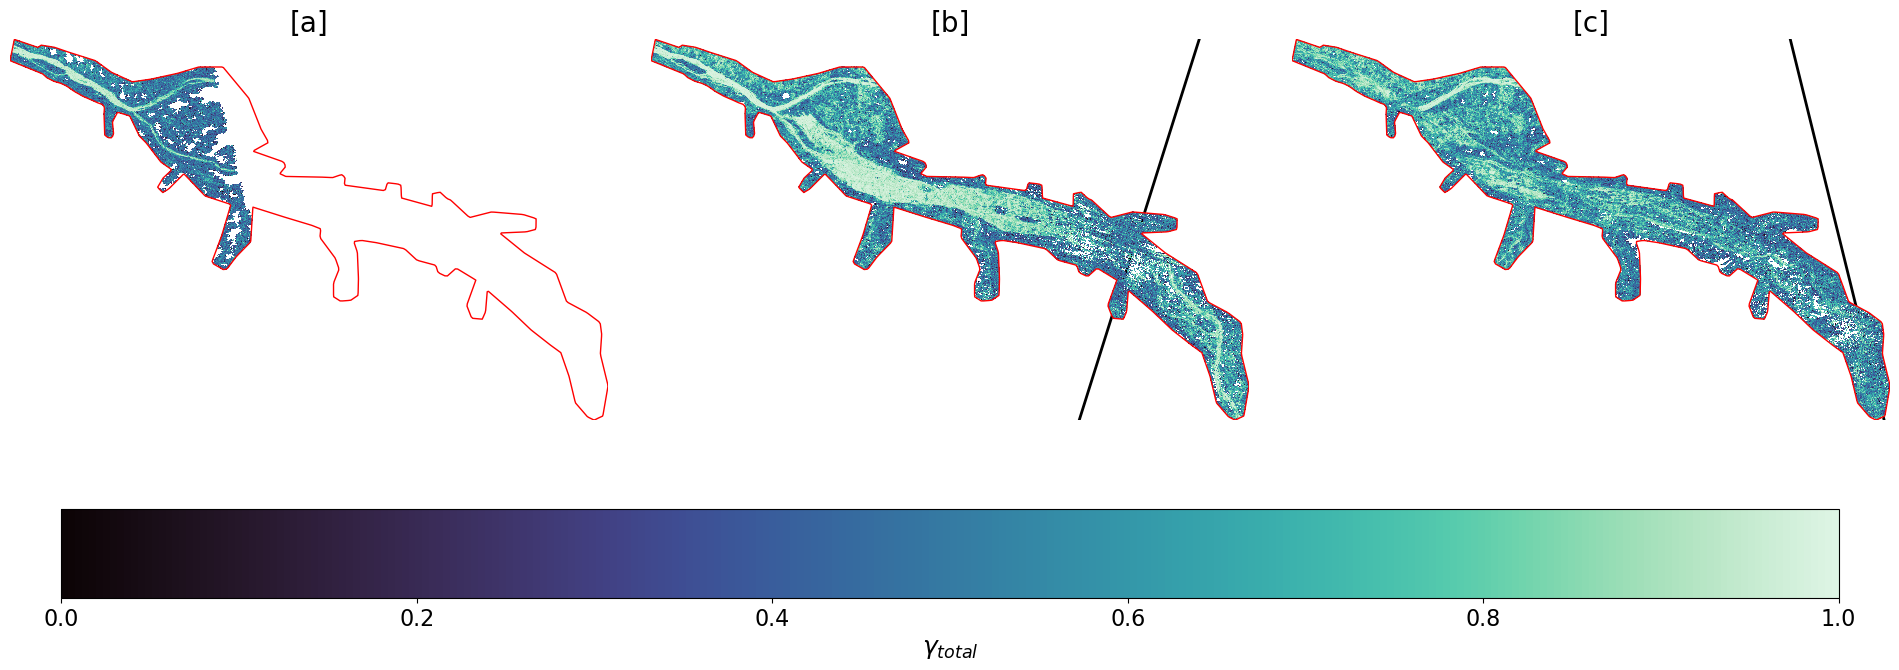

In [19]:
from cartopy import crs as ccrs
dates = ['2024-02-16', "2024-03-31", "2024-04-08"]
title = {'2024-02-16':'[a]', "2024-04-08":'[c]', "2024-03-31":'[b]'}
variable = "gamma_tot"

gdf_nadir113 = gpd.read_file("/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Chinon_T2D/nadir_pass_113.gpkg")
gdf_nadir320 = gpd.read_file("/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Chinon_T2D/nadir_pass_320.gpkg")
gdf_nadir113 = gdf_nadir113.to_crs(epsg=2154)
gdf_nadir320 = gdf_nadir320.to_crs(epsg=2154)
data = swot_project.swot_collection.get_variable(variable, "global", "swot", None)
times = data.time.dt.strftime("%Y-%m-%d").values
idx = [np.where(times == date)[0][0] for date in dates]
data = data.isel(time=idx)

im = data.plot(
    figsize=(20, 7),
    col="time",
    col_wrap=3,
    cmap=Colormap("seaborn:mako").to_matplotlib(),
    vmin=0,
    vmax=1,
    cbar_kwargs={"label": '$\gamma_{total}$', "orientation":'horizontal'},
    )
im.axs.flat[1].plot(gdf_nadir113.geometry.iloc[0].xy[0], gdf_nadir113.geometry.iloc[0].xy[1], color='black', linewidth=2, zorder=0)
im.axs.flat[2].plot(gdf_nadir320.geometry.iloc[0].xy[0], gdf_nadir320.geometry.iloc[0].xy[1], color='black', linewidth=2, zorder=0)
im.cbar.set_label(label="$\gamma_{total}$", fontsize=18)
im.cbar.ax.tick_params(labelsize=16)
for ax, time in zip(im.axs.flat, dates):
    gdf2.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=1)
    ax.set_title(title[time], fontsize=20)
    ax.axis('off')

plt.savefig(f"/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Chinon_T2D/Chinon_{variable}_examples.png", dpi=300, bbox_inches='tight')

# Gamma_tot

Finally, we can plot the data using the plot object.

Below, the function to plot a map.

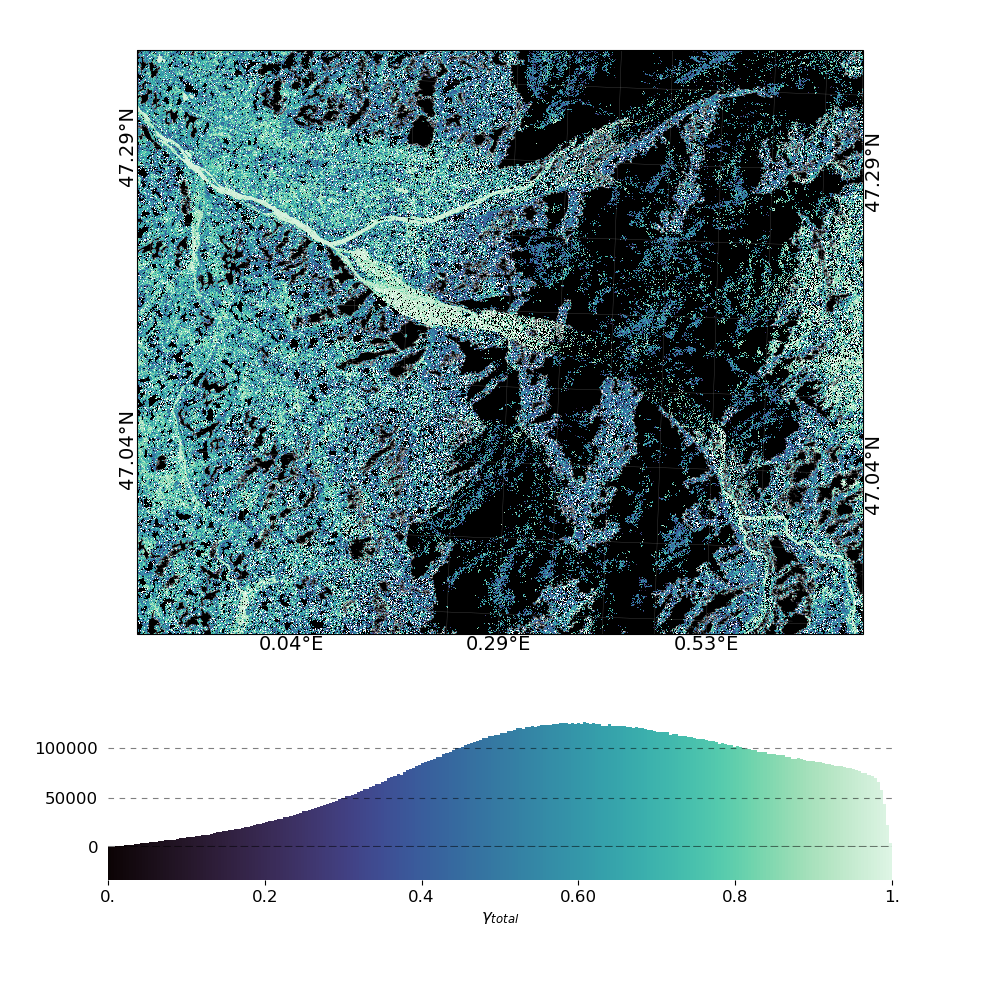

In [20]:
# takes around 1 minute
fig, ax = plot_obj.plot_map(
    variable="gamma_tot",
    data_area="global",
    data_type="swot",
    world_cover_selection=None,
    time_selection="2024-03-31",
    # time_selection="2026-02-18",
    cmap=Colormap("seaborn:mako").to_matplotlib(),
    vmin=0,
    vmax=1,
    add_bkg=False,
    title="",
    save_fig=True
    ) 
plt.show()

Below a function to plot an histogram.

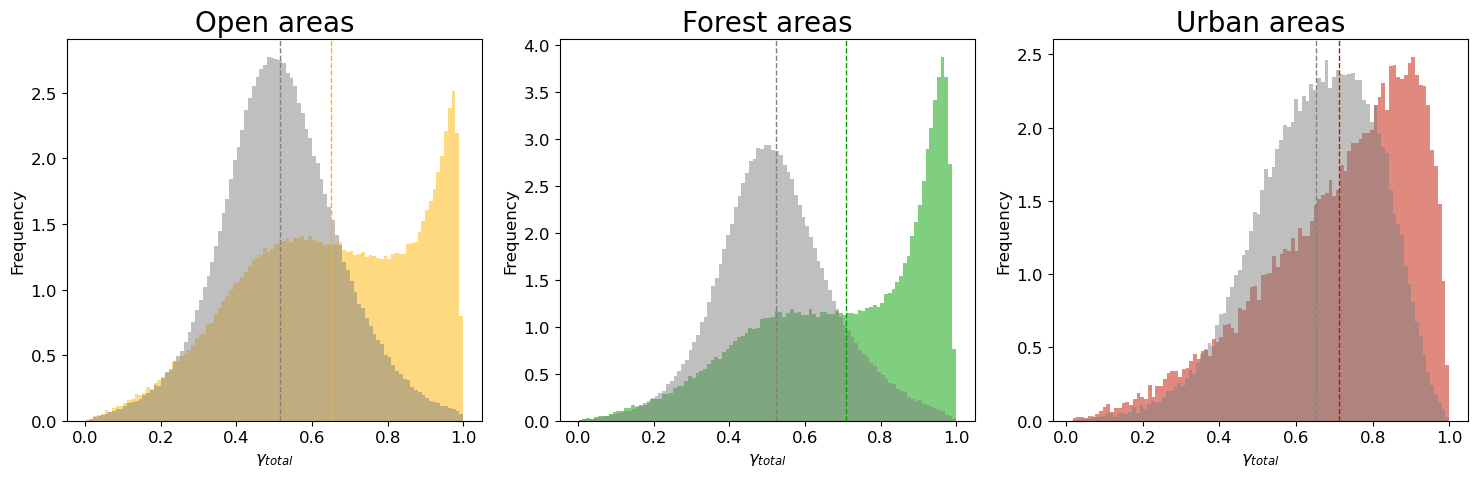

In [7]:
fig, ax = plot_obj.plot_all_histograms(
    variable="gamma_tot",
    data_area="flood",
    data_type="swot",
    time_selection="2024-03-31",
    use_seaborn=False
    )

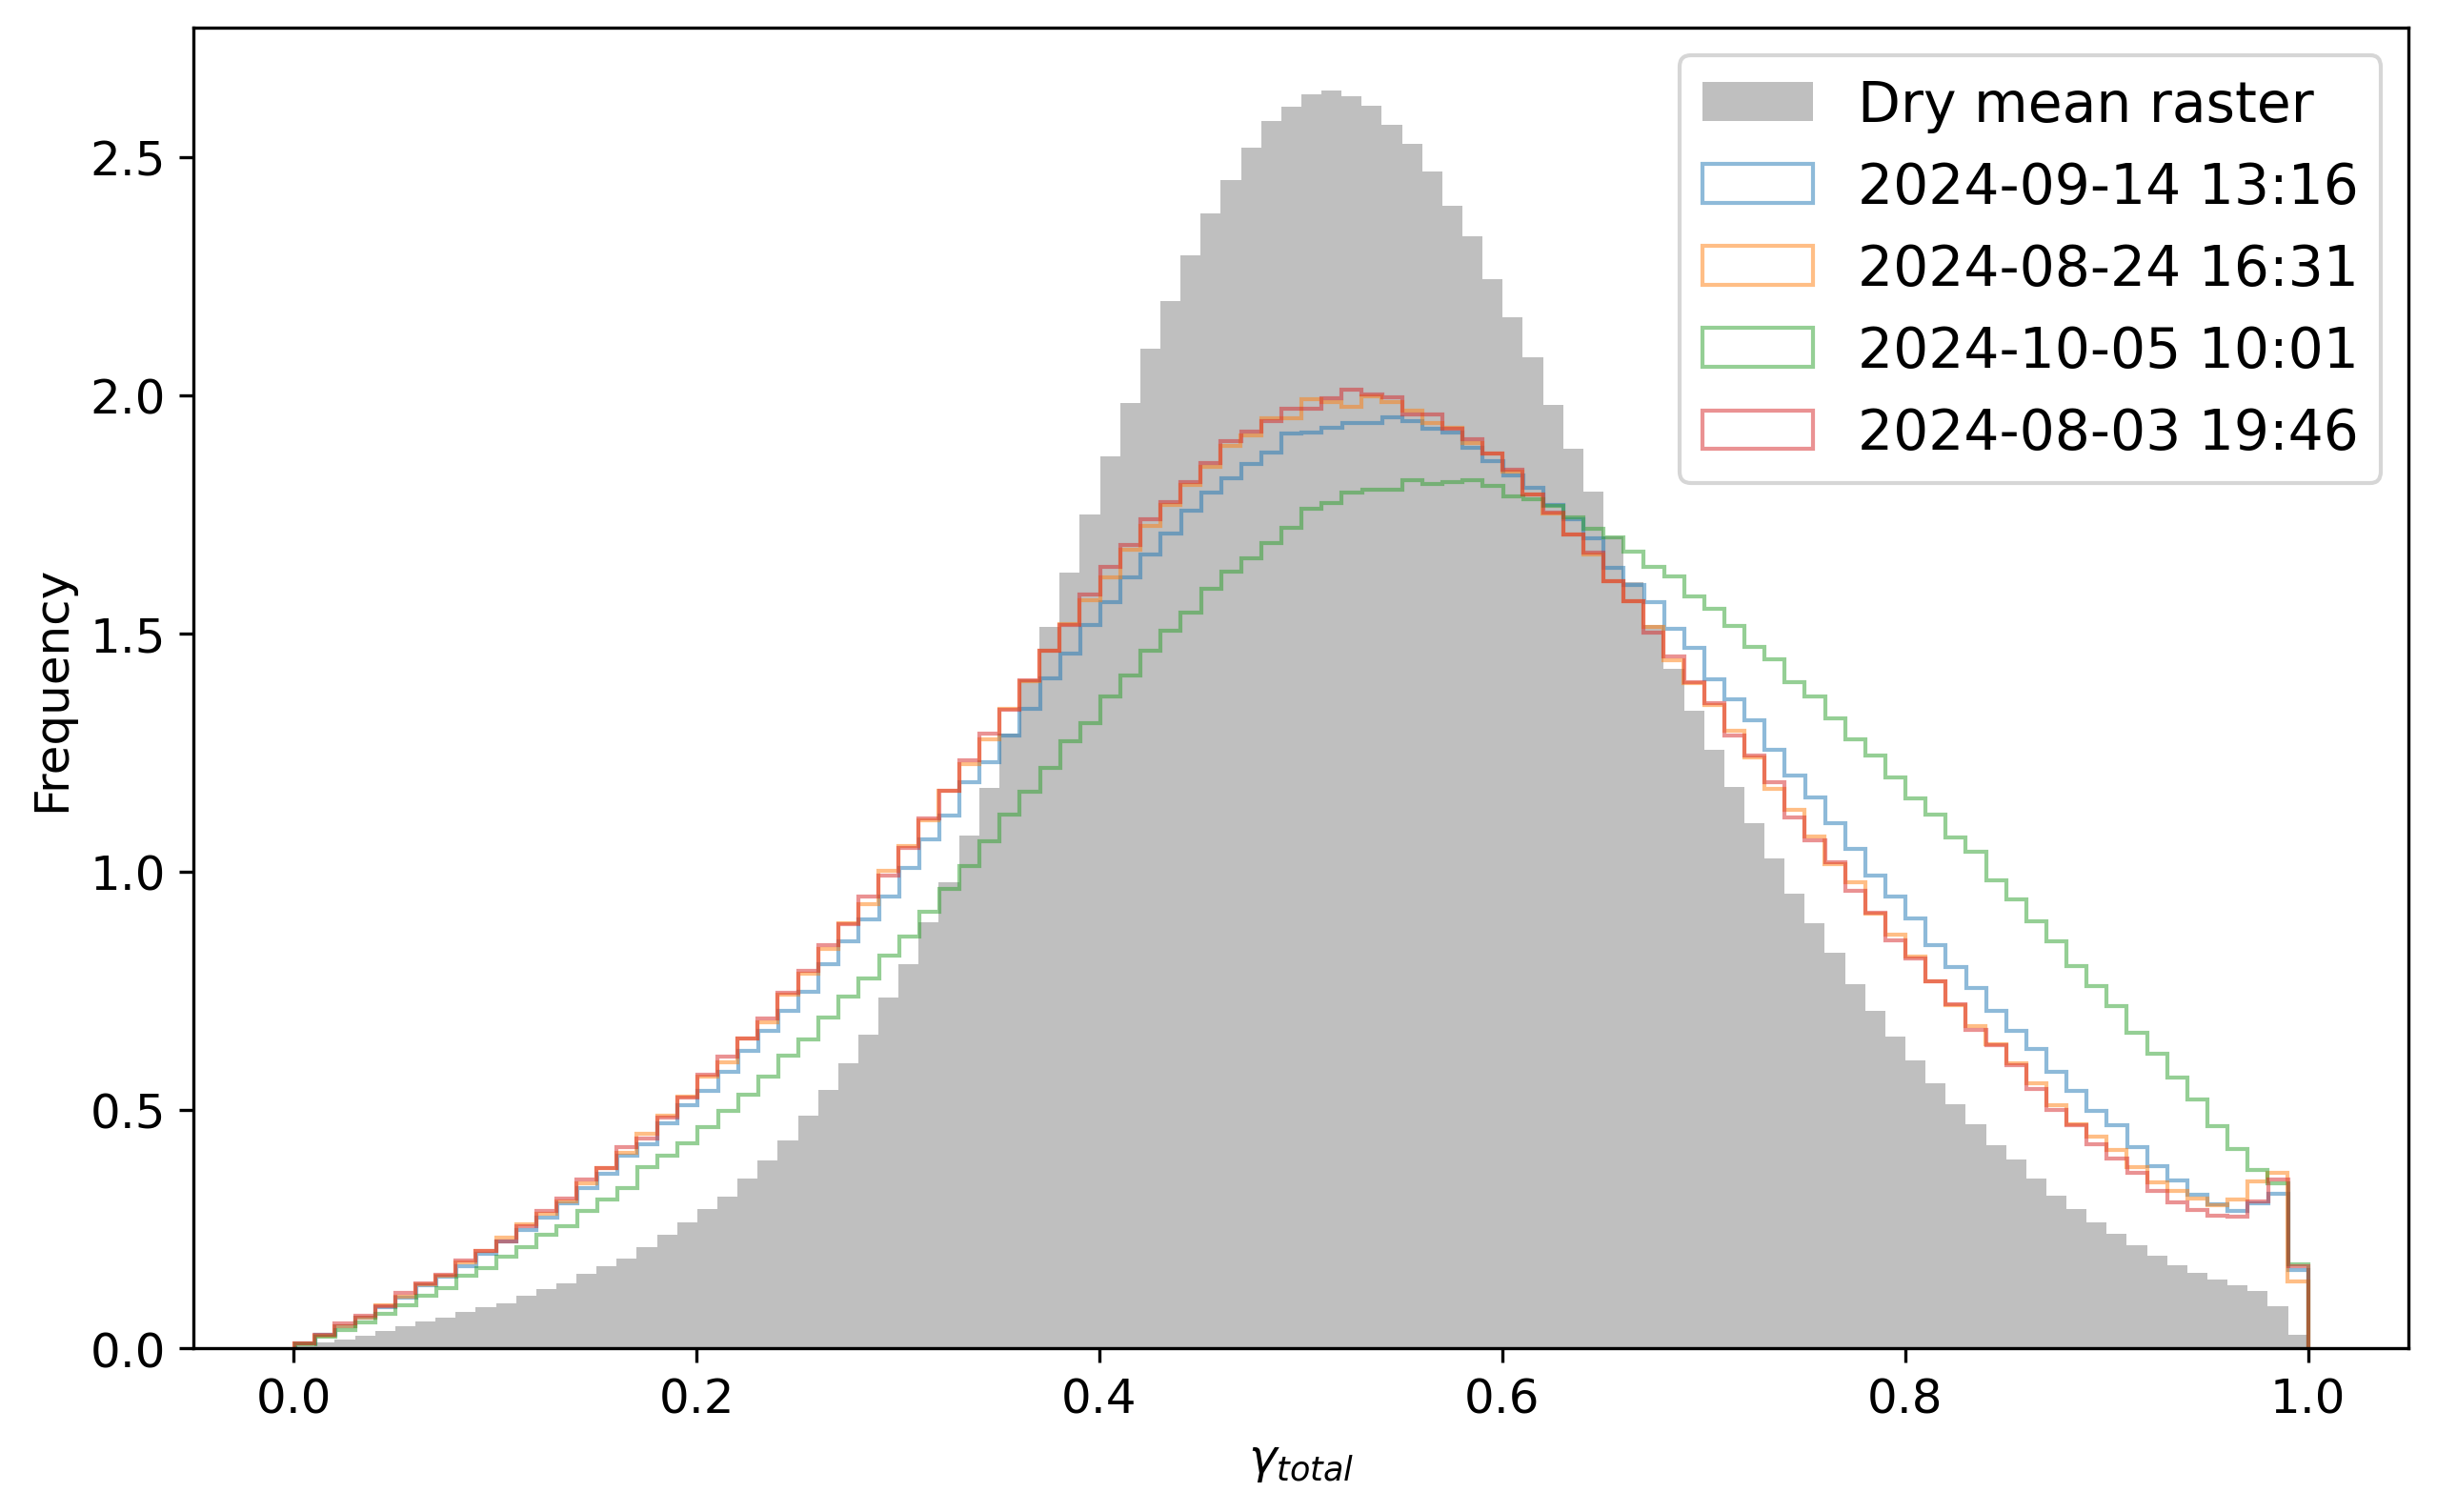

In [ ]:
# takes around 1 minute for seaborn method, 15s for matplotlib method
fig, ax = plt.subplots(figsize=(10,6), dpi=300)
fig, ax = plot_obj.plot_mean_hist_computation(
    variable="gamma_tot",
    fig=fig,
    ax=ax
    )

And then, the function to combine maps and histograms.

In [ ]:
# takes around 1 minute 15s for matplotlib method, 4 minutes for seaborn method
for time in swot_project.list_flood_dates:
    fig, ax = plot_obj.plot_map_with_histogram(
        variable="gamma_tot",
        data_area="global",
        data_type="swot",
        world_cover_mask=['urban'],
        time_selection=time,
        add_bkg=False,
        cmap=Colormap("seaborn:mako").to_matplotlib(),
        use_seaborn=False
        )

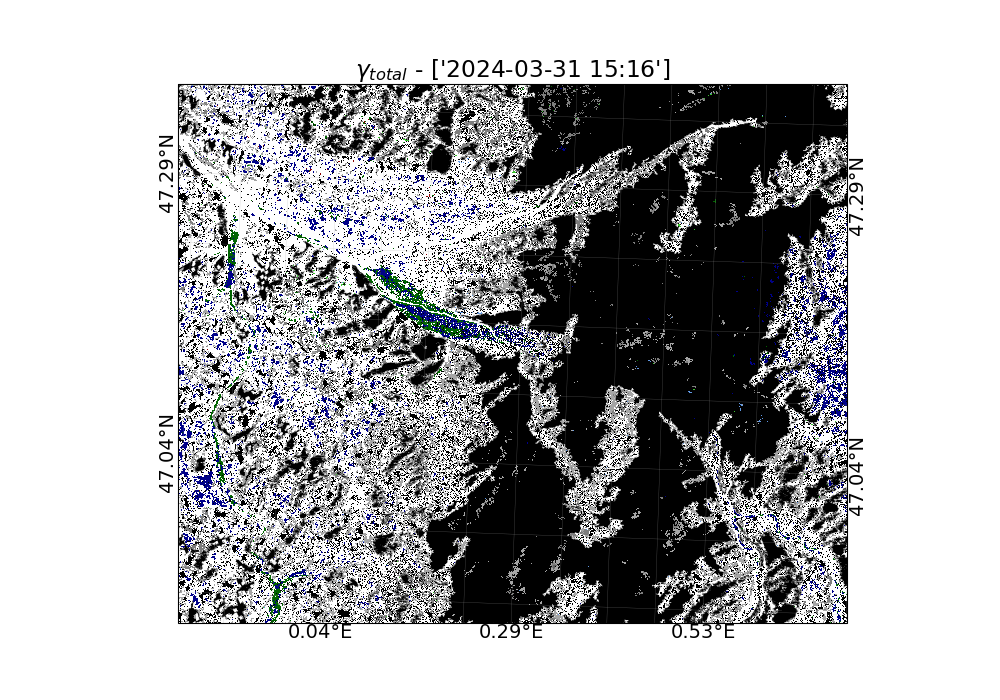

In [19]:
import cartopy
import matplotlib.patches as mpatches

# for time in swot_project.list_flood_dates:
print("Creating flood mask...")
plot_obj.swot_collection.create_flood_mask(
    variable="gamma_tot",
    data_area="global",
    data_type="swot",
    thresholds={"urban":0.9, "forest":0.8, "open":0.8},
    # time_selection="2026-02-18",
    time_selection="2024-03-31",
    add_uncertainty=True,
    threshold_gamma=0.5,
    threshold_SNR=0.5,
    disk_size=5
    )

print("Plotting flood mask...")
fig, ax = plot_obj.plot_map_mask(
    variable="gamma_tot",
    data_area="global",
    data_type="swot",
    # time_selection="2026-02-18",
    time_selection="2024-03-31",
    add_scores=False,
    add_bkg=False,
    add_legend=False,
    figsize=(10,7)
    )
    
    # plot_obj.swot_collection.save_tiff(
    #         variable="gamma_tot",
    #         is_mask=True,
    #         make_binary=True,
    #         remove_lowcoh=True,
    #         data_area="global",
    #         data_type="swot",
    #         path=plot_obj.project.TIFF_PATH.joinpath('output', f'watermask_gamma_tot_{time.replace("-","")}_epsg{plot_obj.project.CRS}.tif'),
    #         time_selection=time,
    #     )

# coherent power

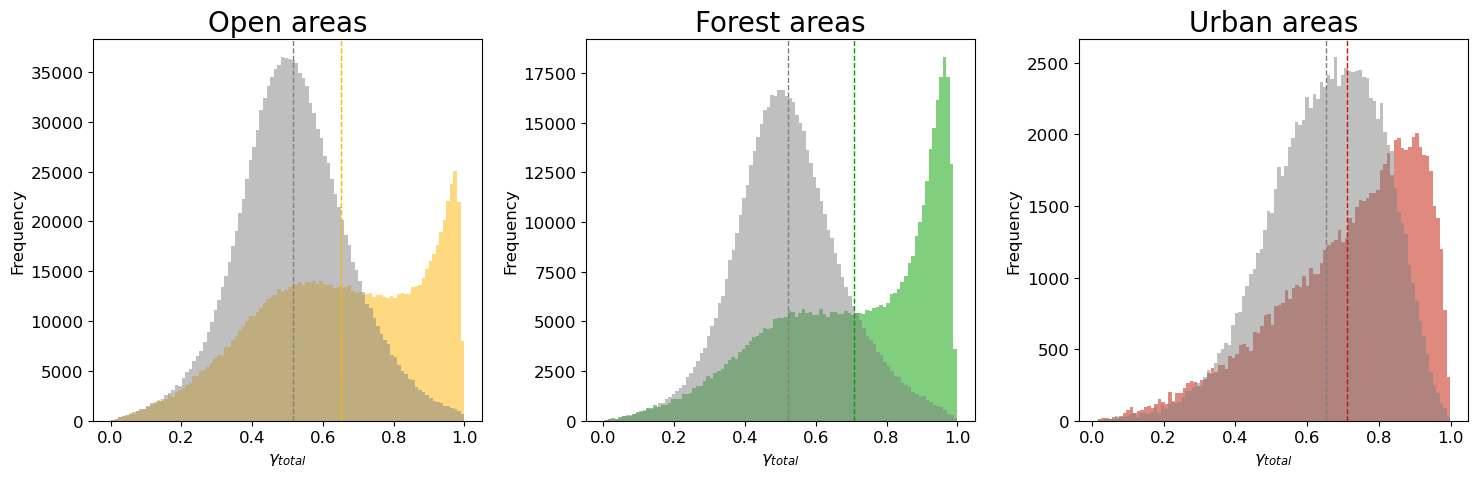

In [19]:
fig, ax = plot_obj.plot_all_histograms(
    variable="gamma_tot",
    data_area="flood",
    data_type="swot",
    time_selection="2024-03-31",
    use_seaborn=False
    )

In [14]:
plot_obj.swot_collection.save_tiff(
    "gamma_tot", 
    is_mask=True, 
    make_binary=False, 
    remove_lowcoh=False, 
    data_area="flood", 
    data_type="swot", 
    path=plot_obj.project.TIFF_PATH.joinpath('output', f'mask_class_gamma_tot_flood_2024-03-31_epsg{plot_obj.project.CRS}.tif'), 
    time_selection="2024-03-31"
    )

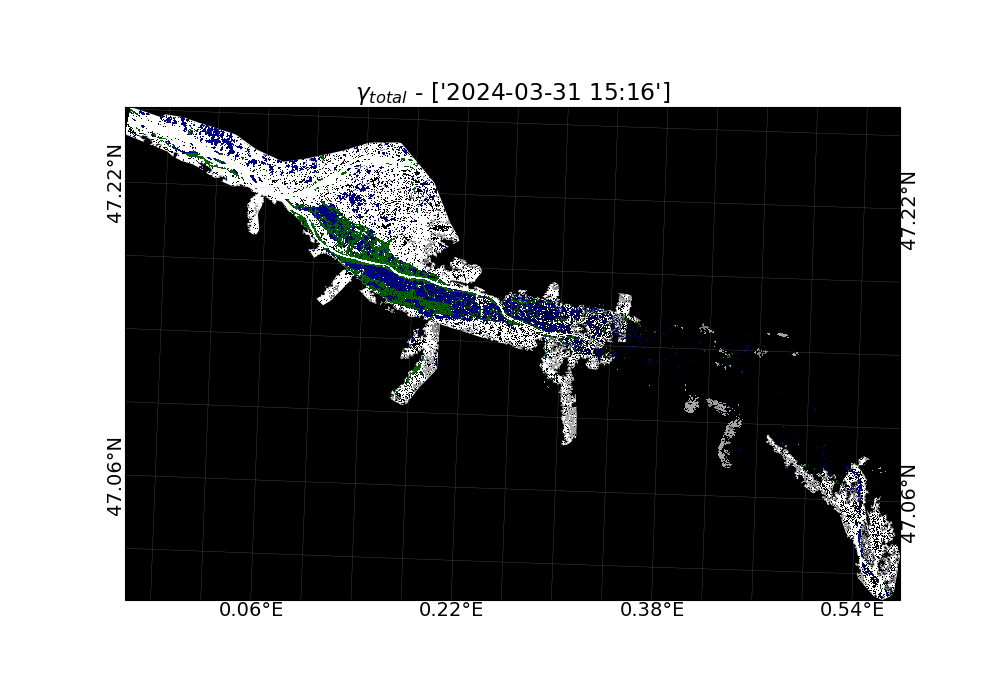

In [12]:
print("Creating flood mask...")
plot_obj.swot_collection.create_flood_mask(
    variable="gamma_tot",
    data_area="flood",
    data_type="swot",
    thresholds={"urban":-0, "forest":0.715, "open":0.715},
    time_selection="2024-03-31",
    add_uncertainty=True,
    )

print("Plotting flood mask...")
fig, ax = plot_obj.plot_map_mask(
    variable="gamma_tot",
    data_area="flood",
    data_type="swot",
    time_selection="2024-03-31",
    # comparing_raster_Path=swot_project.AUX_PATH.joinpath("FM_30TYT_20240331T174856_S1_132_POST_nrow1496_ncol2635.tif"),
    add_scores=False,
    add_bkg=False,
    add_legend=False,
    figsize=(10,7)
    )

In [10]:
plot_obj.swot_collection.save_tiff(
    "gamma_tot", 
    is_mask=True, 
    make_binary=True, 
    remove_lowcoh=True, 
    data_area="flood", 
    data_type="swot", 
    time_selection="2024-03-31",
    path=plot_obj.project.TIFF_PATH.joinpath('output', f'mask_gamma_tot_flood_2024-03-31_epsg{plot_obj.project.CRS}.tif'), 
    )

# Sigma 0

In [ ]:
fig,ax = plot_obj.plot_map(
    variable="sig0",
    data_area="global",
    data_type="diff",
    time_selection="2024-03-31",
    cmap= 'coolwarm',
    vmin=-35,
    vmax=35,
    add_bkg=False,
    )

In [ ]:
fig, ax = plot_obj.plot_all_histograms(
    variable="sig0",
    data_area="global",
    data_type="diff",
    time_selection="2024-03-31",
    use_seaborn=False
    )

In [ ]:
fig, ax = plot_obj.plot_all_histograms(
    variable="sig0",
    data_area="global",
    data_type="swot",
    time_selection="2024-03-31",
    use_seaborn=False
    )

In [ ]:
print("Creating flood mask...")
plot_obj.swot_collection.create_flood_mask(
    variable="sig0",
    data_area="global",
    data_type="swot",
    thresholds={"urban":-0, "forest":10, "open":10},
    time_selection="2024-03-31",
    add_uncertainty=True,
    )

print("Plotting flood mask...")
fig, ax, m_data = plot_obj.plot_map_mask(
    variable="sig0",
    data_area="global",
    data_type="swot",
    time_selection="2024-03-31",
    comparing_raster_Path=swot_project.AUX_PATH.joinpath("FM_30TYT_20240331T174856_S1_132_POST_nrow1496_ncol2635.tif"),
    add_classif_score=True,
    add_uncertainty=True,
    add_bkg=False,
    add_legend=True,
    figsize=(10,7)
    )

ax[0].add_patch(
    mpatches.Rectangle(
        xy=(0.28, 47.1),  # lower left corner
        width=0.03,  # width of rectangle
        height=0.05,  # height of rectangle
        linewidth=2,
        linestyle='--',
        edgecolor="red",
        fill=False,
        transform=cartopy.crs.PlateCarree()._as_mpl_transform(ax[-1]),
    )
)
ax[0].annotate(
    "A",
    xy=(0.28, 47.11),
    fontsize=20,
    color="red",
    ha='center',
    va='center',
    bbox = dict(boxstyle="round", fc="w", ec="w", lw=0, alpha=0.5),
)
m_data.show()

# Merged

In [ ]:
print("Creating flood mask...")
plot_obj.swot_collection.create_flood_mask(
    variable="sig0",
    data_area="global",
    data_type="swot",
    thresholds={"urban":-0, "forest":10, "open":10},
    time_selection="2024-03-31",
    add_uncertainty=True,
    )
plot_obj.swot_collection.create_flood_mask(
    variable="coherent_power",
    data_area="global",
    data_type="swot",
    thresholds={"urban":-0, "forest":64, "open":64},
    time_selection="2024-03-31",
    add_uncertainty=True,
    )
plot_obj.swot_collection.create_flood_mask(
    variable="gamma_tot",
    data_area="global",
    data_type="swot",
    thresholds={"urban":-0, "forest":0.75, "open":0.75},
    time_selection="2024-03-31",
    add_uncertainty=True,
    )

# merging flood masks
print("Merging flood masks...")
plot_obj.swot_collection.merge_flood_masks(data_area="global", data_type="swot", filter_variable="sig0")

print("Plotting flood mask...")
fig, ax = plot_obj.plot_map_mask(
    variable="merged",
    data_area="global",
    data_type="swot",
    time_selection="2024-03-31",
    comparing_raster_Path=swot_project.AUX_PATH.joinpath("FM_30TYT_20240331T174856_S1_132_POST_nrow1496_ncol2635.tif"),
    add_classif_score=True,
    add_uncertainty=True,
    add_bkg=False,
    add_legend=True,
    figsize=(10,7)
    )

# Scores

In [9]:
for variable in ["sig0", "coherent_power", "gamma_tot"]:
    print("-"*69)
    print("variable: ", variable)
    if variable == "sig0":
        Ohio_thresholds={"urban":-0, "forest":5.5, "open":9.5}
        PA_thresholds={"urban":-0, "forest":5, "open":10}
        PA_urban_diff=False
        Greece_thresholds={"urban":8, "forest":7, "open":9}
        Greece_urban_diff=True
        Chinon_thresholds={"urban":-0, "forest":10, "open":10}
        
    elif variable == "coherent_power":
        Ohio_thresholds={"urban":-0, "forest":62.5, "open":65}
        PA_thresholds={"urban":-0, "forest":62, "open":70}
        PA_urban_diff=False
        Greece_thresholds={"urban":70, "forest":65, "open":65}
        Greece_urban_diff=False
        Chinon_thresholds={"urban":-0, "forest":64, "open":64}
        
    elif variable == "gamma_tot":
        Ohio_thresholds={"urban":-0, "forest":0.7, "open":0.85}
        PA_thresholds={"urban":-0.1, "forest":0.65, "open":0.8} # swot with urban diff
        PA_urban_diff=True
        Greece_thresholds={"urban":0.9, "forest":0.85, "open":0.9}
        Greece_urban_diff=False
        Chinon_thresholds={"urban":-0, "forest":0.725, "open":0.725}
        
    # print("Flooded Area")
    # plot_obj.swot_collection.create_flood_mask(
    #     variable=variable,
    #     data_area="flood",
    #     data_type="swot",
    #     thresholds=Chinon_thresholds,
    #     threshold_SNR=0.5,
    #     threshold_gamma=0.5, #swot
    #     time_selection="2024-03-31",
    #     add_uncertainty=True,
    #     )

    # csi, _, _ = plot_obj.swot_collection.compute_scores(
    #     variable=variable,
    #     compared_raster_path=swot_project.AUX_PATH.joinpath("FloodMask_nrow1496_ncol2635.tif"),
    #     data_area="flood",
    #     data_type="swot",
    #     time_selection="2024-03-31",
    #     water_value=1,
    #     nan_value=-9999
    #     )
    # print("SWOT x HM       ", round(csi * 100, 2))
    
    # csi, _, _ = plot_obj.swot_collection.compute_scores(
    #     variable="classification",
    #     compared_raster_path=swot_project.AUX_PATH.joinpath("FloodMask_nrow1496_ncol2635.tif"),
    #     data_area="flood",
    #     data_type="swot",
    #     time_selection="2024-03-31",
    #     water_value=1,
    #     nan_value=-9999
    #     )
    # print("classif x HM    ", round(csi * 100, 2))
    
    # csi, _, _ = plot_obj.swot_collection.compute_scores(
    #     variable=variable,
    #     compared_raster_path=swot_project.AUX_PATH.joinpath("FM_30TYT_20240331T174856_S1_132_POST_nrow1496_ncol2635.tif"),
    #     data_area="flood",
    #     data_type="swot",
    #     time_selection="2024-03-31",
    #     water_value=1,
    #     nan_value=-9999
    #     )
    # print("SWOT x FM       ", round(csi * 100, 2))

    # csi, _, _ = plot_obj.swot_collection.compute_scores(
    #     variable="classification",
    #     compared_raster_path=swot_project.AUX_PATH.joinpath("FM_30TYT_20240331T174856_S1_132_POST_nrow1496_ncol2635.tif"),
    #     data_area="flood",
    #     data_type="swot",
    #     time_selection="2024-03-31",
    #     water_value=1,
    #     nan_value=-9999
    #     )
    # print("classif x FM    ", round(csi * 100, 2))

    # csi, _, _ = plot_obj.swot_collection.compute_scores(
    #     variable=variable,
    #     compared_raster_path="classification",
    #     data_area="flood",
    #     data_type="swot",
    #     time_selection="2024-03-31",
    #     water_value=1,
    #     nan_value=-9999
    #     )
    # print("SWOT x classif  ", round(csi * 100, 2))

    #############
    print("Global Area")
    plot_obj.swot_collection.create_flood_mask(
        variable=variable,
        data_area="global",
        data_type="swot",
        thresholds=Chinon_thresholds,
        threshold_SNR=0.5,
        threshold_gamma=0.5, #swot
        time_selection="2024-03-31",
        add_uncertainty=True,
        )

    csi, _, _ = plot_obj.swot_collection.compute_scores(
        variable=variable,
        compared_raster_path=swot_project.AUX_PATH.joinpath("FloodMask_nrow1496_ncol2635.tif"),
        data_area="global",
        data_type="swot",
        time_selection="2024-03-31",
        water_value=1,
        nan_value=-9999
        )
    print("SWOT x HM       ", round(csi * 100, 2))
    
    csi, _, _ = plot_obj.swot_collection.compute_scores(
        variable="classification",
        compared_raster_path=swot_project.AUX_PATH.joinpath("FloodMask_nrow1496_ncol2635.tif"),
        data_area="global",
        data_type="swot",
        time_selection="2024-03-31",
        water_value=1,
        nan_value=-9999
        )
    print("classif x HM    ", round(csi * 100, 2))
    
    csi, _, _ = plot_obj.swot_collection.compute_scores(
        variable=variable,
        compared_raster_path=swot_project.AUX_PATH.joinpath("FM_30TYT_20240331T174856_S1_132_POST_nrow1496_ncol2635.tif"),
        data_area="global",
        data_type="swot",
        time_selection="2024-03-31",
        water_value=1,
        nan_value=-9999
        )
    print("SWOT x FM       ", round(csi * 100, 2))

    csi, _, _ = plot_obj.swot_collection.compute_scores(
        variable="classification",
        compared_raster_path=swot_project.AUX_PATH.joinpath("FM_30TYT_20240331T174856_S1_132_POST_nrow1496_ncol2635.tif"),
        data_area="global",
        data_type="swot",
        time_selection="2024-03-31",
        water_value=1,
        nan_value=-9999
        )
    print("classif x FM    ", round(csi * 100, 2))

    csi, _, _ = plot_obj.swot_collection.compute_scores(
        variable=variable,
        compared_raster_path="classification",
        data_area="global",
        data_type="swot",
        time_selection="2024-03-31",
        water_value=1,
        nan_value=-9999
        )
    print("SWOT x classif  ", round(csi * 100, 2))



In [10]:
import numpy as np

time_selection = "2024-03-31"
compared_raster_path = swot_project.AUX_PATH.joinpath("FM_30TYT_20240331T174856_S1_132_POST_nrow1496_ncol2635.tif")
_, mask_FloodML = plot_obj.swot_collection.pretreat_data_for_score(
    "classification", 
    compared_raster_path, 
    'global', 
    'swot', 
    time_selection, 
    1, 
    -9999
    )

compared_raster_path = swot_project.AUX_PATH.joinpath("FloodMask_nrow1496_ncol2635.tif")
_, mask_homemade = plot_obj.swot_collection.pretreat_data_for_score(
    "classification", 
    compared_raster_path, 
    'global', 
    'swot', 
    time_selection, 
    1, 
    -9999
    )

if np.count_nonzero(~np.isnan(mask_FloodML)) != np.count_nonzero(~np.isnan(mask_homemade)):
    print("WARNING: The compared raster and the SWOT Raster data have not the same non-nan number of pixels")

# compute TP, FP, TN, FN
true = mask_homemade
pred = mask_FloodML

contingency_map = np.ones(true.shape) * np.nan
contingency_map[np.logical_and(true == 1, pred == 1)] = 1 #'TP'
contingency_map[np.logical_and(true == 0, pred == 0)] = 0 #'TN'
contingency_map[np.logical_and(true == 0, pred == 1)] = 2 #'FP'
contingency_map[np.logical_and(true == 1, pred == 0)] = 3 #'FN'

TP_scale = np.nansum(contingency_map == 1)
TN_scale = np.nansum(contingency_map == 0)
FP_scale = np.nansum(contingency_map == 2)
FN_scale = np.nansum(contingency_map == 3)
total = TP_scale + FP_scale + TN_scale + FN_scale
if total != (~np.isnan(true)).flatten().sum():
    print("WARNING: The sum of TP, FP, TN and FN is not equal to the number of non-nan pixels in the compared raster data")
    
# compute critical success index (CSI)
if TP_scale + FP_scale + FN_scale == 0:
    CSI = 0
else:
    CSI = TP_scale / (TP_scale + FP_scale + FN_scale)

print("CSI: ", round(CSI * 100, 2))